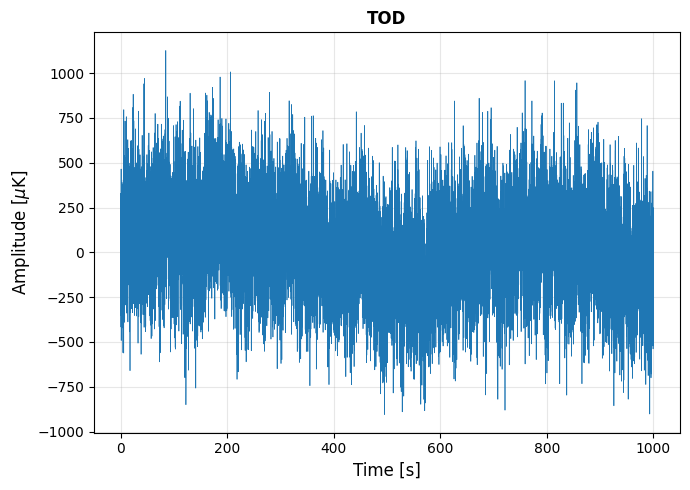

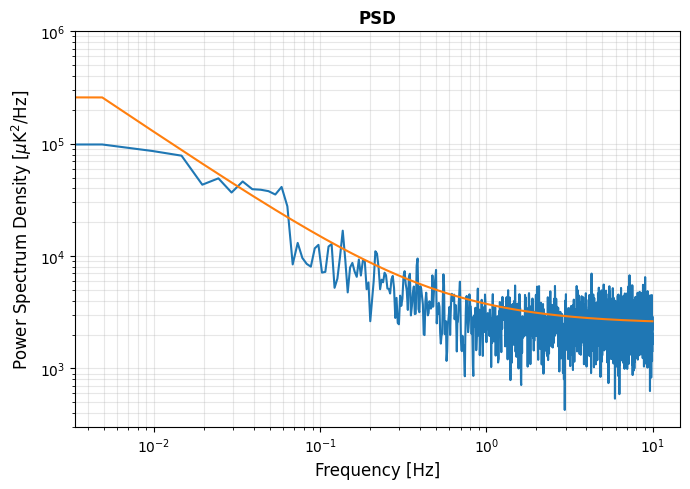

In [6]:
import sys, os
sys.path.append(os.path.abspath("../mylib_project"))

from mylib import add_OofaNoise

import litebird_sim as lbs
from astropy.time import Time
import numpy as np
from scipy.signal import welch
import matplotlib.pyplot as plt
import ducc0

start_time = 0
time_span_s = 1000.0

sim = lbs.Simulation(
    start_time=start_time,
    duration_s=time_span_s,
    random_seed=12345,
    imo=lbs.Imo(flatfile_location=lbs.PTEP_IMO_LOCATION) 
)

sim.set_scanning_strategy(
    lbs.SpinningScanningStrategy(
        spin_sun_angle_rad=np.deg2rad(0),
        precession_rate_hz=0,
        spin_rate_hz=1 / 60,
        start_time=start_time,
    ),
    delta_time_s=5.0,
)

sim.set_instrument(
    lbs.InstrumentInfo(
        boresight_rotangle_rad=0.0,
        spin_boresight_angle_rad=np.deg2rad(90),
        spin_rotangle_rad=np.deg2rad(75),
    )
)

det = lbs.DetectorInfo(
    name="Boresight_detector",
    sampling_rate_hz=20.,
    bandcenter_ghz=100.0,
    net_ukrts=50.0,
    fknee_mhz=500.,
    fmin_hz=1e-5,
    alpha=1
)


sim.create_observations(detectors=det)

tod = sim.observations[0].tod 

# Noise from ducc0
add_OofaNoise(tod, det, block_duration_s=100) 


# PSD with Welch
frequencies, psd = welch(
    tod,
    fs=det.sampling_rate_hz,           
    window='hann',            
    nperseg=2**12,            
    noverlap=2**12 // 2,       
    scaling='density',    
    return_onesided=False
)

sort_idx = np.argsort(frequencies)
frequencies = frequencies[sort_idx]
psd = psd[:, sort_idx]




# PLOT: TOD
plt.figure(figsize=(7, 5))
time_axis = np.arange(tod.shape[1]) / det.sampling_rate_hz
plt.plot(time_axis, tod[0] * 1e6, linewidth=0.5)

plt.xlabel('Time [s]', fontsize=12)
plt.ylabel(r'Amplitude [$\mu$K]', fontsize=12)
plt.title('TOD', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("graph_tod.pdf") 
plt.show()


# PLOT: PSD 
plt.figure(figsize=(7, 5))
f = frequencies
f_knee = det.fknee_mhz / 1000.0  
f_min = det.fmin_hz

# Calcolo PSD teorica
theoretical_psd = (det.net_ukrts**2) * ( (f**det.alpha + f_knee**det.alpha) / (f**det.alpha + f_min**det.alpha) )

plt.loglog(frequencies, psd[0] * 1e12, label='Measured PSD', linewidth=1.5)
plt.loglog(frequencies, theoretical_psd, label='Theoretical PSD', linewidth=1.5)

plt.xlabel('Frequency [Hz]', fontsize=12)
plt.ylabel(r'Power Spectrum Density [$\mu$K$^2$/Hz]', fontsize=12)
plt.title('PSD', fontweight='bold')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.ylim(3e2, 1e6)

plt.tight_layout()
plt.savefig("graph_psd.pdf") 
plt.show()